# Ablation diagnostics — window-shrink

Reusable per-ablation diagnostic. Set `EXP_NAME` below and run top-to-bottom. Two legs:
1. **Mechanism** — same-star reconstruction overlay + power spectrum vs the 1024 baseline: does the smaller window keep fast structure the 1024 decoder smoothed away?
2. **Bellwether** — control-baseline PR-AUC (trained / untrained / summary-stat / label-shuffle / base rate) and the **trained-untrained gap** at each window. Gate = does training add more at the small window than the +0.008 it added at 1024?

Figures + the gap table are written to `experiments/<EXP_NAME>/figs/`.

In [1]:
# --- parameters ---
EXP_NAME = "exp01_window256_seq16"   # the ablation under test
BASELINE = "exp00_window1024_seq4"   # reference geometry for the same-star comparison
VARIANT, SEED = "B", 0
N_EXAMPLES = {"pulsating": 2, "eb": 1, "quiet": 1}   # example stars for the recon overlay

import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import find_peaks
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
warnings.filterwarnings("ignore")

root = Path(r"C:\git_repo\Stellar-World-Model")
sys.path.insert(0, str(root / "src"))
from swm.models import WorldModel
device = "cuda" if torch.cuda.is_available() else "cpu"
TASKS = ["transit", "eb", "pulsating"]
MU_COLS = [f"mu{j}" for j in range(128)]
figs_dir = root / "experiments" / EXP_NAME / "figs"; figs_dir.mkdir(parents=True, exist_ok=True)
print("device", device, "| EXP", EXP_NAME, "| figs ->", figs_dir)

device cuda | EXP exp01_window256_seq16 | figs -> C:\git_repo\Stellar-World-Model\experiments\exp01_window256_seq16\figs


In [2]:
# --- loaders: trained/untrained models + packed memmaps, per experiment ---
def load_trained(exp_name, variant=VARIANT):
    ck = torch.load(root/"experiments"/exp_name/f"models/{variant}_seed{SEED}/best.pt", map_location=device, weights_only=False)
    c = ck["cfg"]; w = int(c["data"]["window"])
    m = WorldModel(in_ch=c["model"]["in_ch"], enc_channels=c["model"]["enc_channels"], kernel_size=c["model"]["kernel_size"],
                   z_dim=c["model"]["z_dim"], window=w, gru_hidden=c["model"]["gru_hidden"], gru_layers=c["model"]["gru_layers"]).to(device)
    m.load_state_dict(ck["model"]); m.eval(); return m, w, c

def make_untrained(cfg, window):
    torch.manual_seed(0)  # fixed init -> reproducible untrained baseline
    c = cfg["model"]
    return WorldModel(in_ch=c["in_ch"], enc_channels=c["enc_channels"], kernel_size=c["kernel_size"],
                      z_dim=c["z_dim"], window=window, gru_hidden=c["gru_hidden"], gru_layers=c["gru_layers"]).to(device).eval()

def load_packed(exp_name, split, window):
    pk = root/"experiments"/exp_name/"packed"
    idx = pd.read_parquet(pk/f"{split}_index.parquet")
    total = int(idx["n_win"].sum())
    mm = np.memmap(pk/f"{split}_windows.dat", dtype=np.float32, mode="r", shape=(total, window))
    first = idx.sort_values(["tic_id","sector","seg_idx"]).drop_duplicates("tic_id").set_index("tic_id")
    return idx, mm, first

subset = pd.read_parquet(root/"processed/subset/subset_tics.parquet")
model_e, W_E, cfg_e = load_trained(EXP_NAME)
model_b, W_B, cfg_b = load_trained(BASELINE)
print("windows: exp", W_E, "| baseline", W_B)

windows: exp 256 | baseline 1024


## Leg 1 — same-star reconstruction
For a few test stars: overlay the input flux with the trained recon at 1024 vs 256 (time domain, zoomed), and compare power spectra. **Low-pass** = recon power falls below the input at high frequency. **Retained structure** = recon power tracks the input further out. The input is identical across windowings (asserted) — only the recon differs.

In [3]:
def first_seg_input_recon(model, first, mm, tic):
    r = first.loc[tic]; blk = np.array(mm[int(r.row_start):int(r.row_start)+int(r.n_win)], dtype=np.float32)
    x = torch.from_numpy(blk).unsqueeze(-1).to(device)
    with torch.no_grad():
        mu,_ = model.encoder(x); rec = model.decoder(mu)
    return blk.reshape(-1), rec[:,:,0].cpu().numpy().reshape(-1)

_, mm_te_e, first_te_e = load_packed(EXP_NAME, "test", W_E)
_, mm_te_b, first_te_b = load_packed(BASELINE, "test", W_B)

test_lab = subset[subset["split"]=="test"]
def pick(task, n):
    if task == "quiet":
        s = test_lab[test_lab[["transit","eb","pulsating"]].sum(axis=1)==0]
    else:
        s = test_lab[test_lab[task]==1]
    tics = [int(t) for t in np.sort(s["tic_id"].to_numpy()) if t in first_te_e.index and t in first_te_b.index]
    return tics[:n]
examples = [(t, task) for task, n in N_EXAMPLES.items() for t in pick(task, n)]
print("example stars:", examples)

example stars: [(823820, 'pulsating'), (1221946, 'pulsating'), (5703872, 'eb'), (55344, 'quiet')]


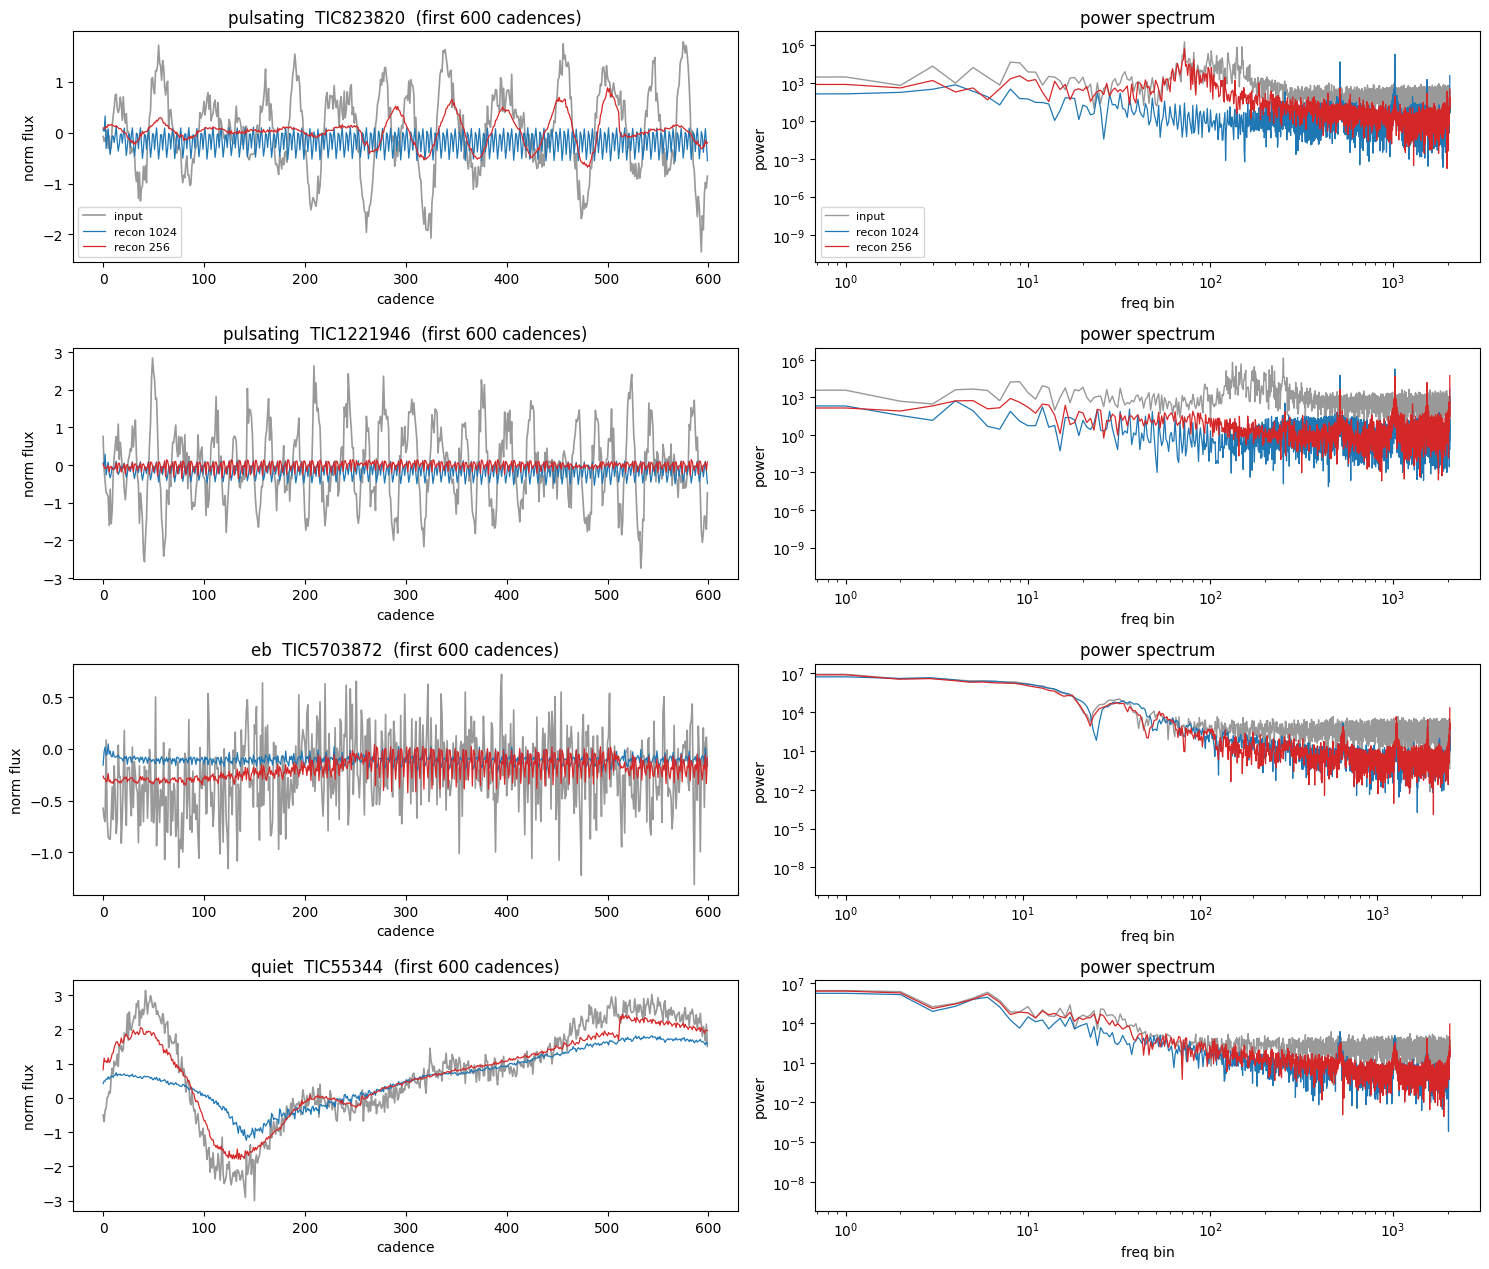

saved C:\git_repo\Stellar-World-Model\experiments\exp01_window256_seq16\figs\recon_overlay_exp01_window256_seq16.png


In [4]:
def psd(x):
    return np.abs(np.fft.rfft(x - x.mean()))**2

fig, axes = plt.subplots(len(examples), 2, figsize=(15, 3.2*len(examples)))
if len(examples) == 1: axes = axes[None, :]
for i,(tic,task) in enumerate(examples):
    in_b, rec_b = first_seg_input_recon(model_b, first_te_b, mm_te_b, tic)
    in_e, rec_e = first_seg_input_recon(model_e, first_te_e, mm_te_e, tic)
    assert np.allclose(in_b, in_e, atol=1e-4), "same-star input must match across windowings"
    zoom = min(600, len(in_b))
    ax = axes[i,0]
    ax.plot(in_b[:zoom], color="0.6", lw=1.2, label="input")
    ax.plot(rec_b[:zoom], color="tab:blue", lw=0.9, label=f"recon {W_B}")
    ax.plot(rec_e[:zoom], color="tab:red", lw=0.9, label=f"recon {W_E}")
    ax.set_title(f"{task}  TIC{tic}  (first {zoom} cadences)"); ax.set_xlabel("cadence"); ax.set_ylabel("norm flux")
    if i == 0: ax.legend(fontsize=8)
    ax = axes[i,1]
    ax.loglog(psd(in_b), color="0.6", lw=1.0, label="input")
    ax.loglog(psd(rec_b), color="tab:blue", lw=0.9, label=f"recon {W_B}")
    ax.loglog(psd(rec_e), color="tab:red", lw=0.9, label=f"recon {W_E}")
    ax.set_title("power spectrum"); ax.set_xlabel("freq bin"); ax.set_ylabel("power")
    if i == 0: ax.legend(fontsize=8)
plt.tight_layout(); fig.savefig(figs_dir/f"recon_overlay_{EXP_NAME}.png", dpi=120, bbox_inches="tight"); plt.show()
print("saved", figs_dir/f"recon_overlay_{EXP_NAME}.png")

## Leg 2 — control baselines + the trained-untrained gap
The gate. Both trained and untrained encoders gain capacity from a smaller window, so we measure the gap at each window with an identical **first-segment** feature pipeline (per-star mean posterior mu over the star's first segment). `gap_widened` > 0 for pulsating means training adds more at the small window than at 1024.

In [5]:
def rep_features(model, exp_name, window):
    """Per-star mean posterior mu over the star's first segment (train+test)."""
    _, mm_tr, first_tr = load_packed(exp_name, "train", window)
    _, mm_te, first_te = load_packed(exp_name, "test", window)
    recs = []
    for split, first, mm in [("train",first_tr,mm_tr), ("test",first_te,mm_te)]:
        for tic in first.index:
            r = first.loc[tic]; blk = np.array(mm[int(r.row_start):int(r.row_start)+int(r.n_win)], dtype=np.float32)
            x = torch.from_numpy(blk).unsqueeze(-1).to(device)
            with torch.no_grad(): mu,_ = model.encoder(x)
            recs.append((int(tic), split, mu.mean(0).cpu().numpy()))
    df = pd.DataFrame([r[2] for r in recs], columns=MU_COLS)
    df.insert(0, "tic_id", [r[0] for r in recs]); df["split"] = [r[1] for r in recs]
    return df.merge(subset[["tic_id"]+TASKS], on="tic_id")

def probe(df, cols, task):
    tr, te = df[df.split=="train"], df[df.split=="test"]
    if tr[task].nunique() < 2 or te[task].nunique() < 2: return np.nan
    sc = StandardScaler(); xtr = sc.fit_transform(tr[cols]); xte = sc.transform(te[cols])
    clf = LogisticRegression(class_weight="balanced", max_iter=2000).fit(xtr, tr[task])
    return float(average_precision_score(te[task], clf.predict_proba(xte)[:,1]))

In [6]:
# slow part: 4 encoder passes over ~11k stars' first segments (trained/untrained x 256/1024)
feat = {
    ("trained",   W_E): rep_features(model_e, EXP_NAME, W_E),
    ("untrained", W_E): rep_features(make_untrained(cfg_e, W_E), EXP_NAME, W_E),
    ("trained",   W_B): rep_features(model_b, BASELINE, W_B),
    ("untrained", W_B): rep_features(make_untrained(cfg_b, W_B), BASELINE, W_B),
}
print("feature tables:", {f"{k[0]}@{k[1]}": v.shape for k,v in feat.items()})

feature tables: {'trained@256': (11449, 133), 'untrained@256': (11449, 133), 'trained@1024': (11449, 133), 'untrained@1024': (11449, 133)}


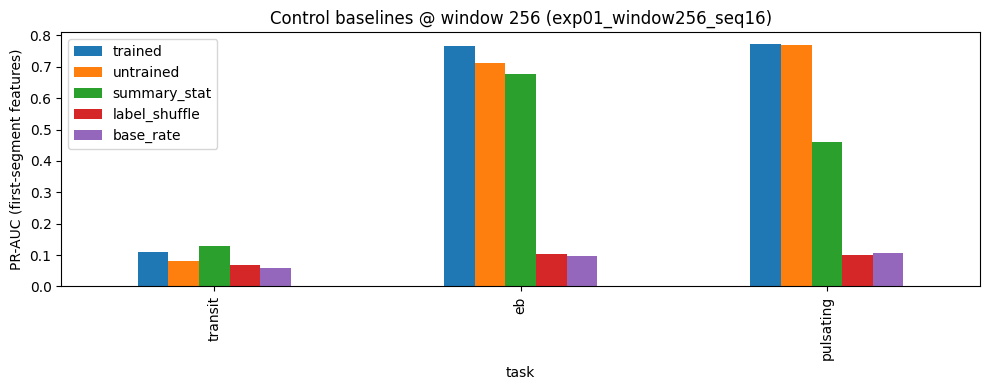

,trained,untrained,summary_stat,label_shuffle,base_rate
task,,,,,
transit,0.1111,0.0805,0.1295,0.0680,0.0604
eb,0.7651,0.7124,0.6776,0.1038,0.0970
pulsating,0.7711,0.7678,0.4590,0.1018,0.1069


In [7]:
# summary-stat features at the exp window, matching the baseline D-section control set
def summary_feats(exp_name, window):
    _, mm_tr, first_tr = load_packed(exp_name, "train", window)
    _, mm_te, first_te = load_packed(exp_name, "test", window)
    rows = []
    for split, first, mm in [("train",first_tr,mm_tr), ("test",first_te,mm_te)]:
        for tic in first.index:
            r = first.loc[tic]; lc = np.array(mm[int(r.row_start):int(r.row_start)+int(r.n_win)], dtype=np.float32).reshape(-1)
            std = float(np.std(lc))
            rows.append((int(tic), split, std, float(np.median(np.abs(lc-np.median(lc)))),
                         float(stats.skew(lc)) if std>0 else 0.0, float(stats.kurtosis(lc)) if std>0 else 0.0,
                         float(np.ptp(lc)), int(len(find_peaks(lc)[0]))))
    scols = ["std","mad","skew","kurt","range","n_peaks"]
    df = pd.DataFrame([r[2:] for r in rows], columns=scols)
    df.insert(0, "tic_id", [r[0] for r in rows]); df["split"] = [r[1] for r in rows]
    return df.merge(subset[["tic_id"]+TASKS], on="tic_id"), scols
stat_df, scols = summary_feats(EXP_NAME, W_E)

rows = []
for t in TASKS:
    te = feat[("trained",W_E)]; base = float(te[te.split=="test"][t].mean())
    sh = feat[("trained",W_E)].copy(); sh[t] = np.random.default_rng(0).permutation(sh[t].to_numpy())
    rows.append({"task":t, "trained":probe(feat[("trained",W_E)],MU_COLS,t), "untrained":probe(feat[("untrained",W_E)],MU_COLS,t),
                 "summary_stat":probe(stat_df,scols,t), "label_shuffle":probe(sh,MU_COLS,t), "base_rate":base})
ctrl = pd.DataFrame(rows).set_index("task")
ax = ctrl[["trained","untrained","summary_stat","label_shuffle","base_rate"]].plot.bar(figsize=(10,4))
ax.set_ylabel("PR-AUC (first-segment features)"); ax.set_title(f"Control baselines @ window {W_E} ({EXP_NAME})")
plt.tight_layout(); ax.get_figure().savefig(figs_dir/f"control_baselines_{EXP_NAME}.png", dpi=120, bbox_inches="tight"); plt.show()
ctrl.round(4)

In [8]:
# THE GATE: trained - untrained gap at each window (consistent first-segment pipeline)
gap_rows = []
for t in TASKS:
    tr_e = probe(feat[("trained",W_E)],MU_COLS,t); un_e = probe(feat[("untrained",W_E)],MU_COLS,t)
    tr_b = probe(feat[("trained",W_B)],MU_COLS,t); un_b = probe(feat[("untrained",W_B)],MU_COLS,t)
    gap_rows.append({"task":t, f"trained_{W_B}":tr_b, f"untrained_{W_B}":un_b, f"gap_{W_B}":tr_b-un_b,
                     f"trained_{W_E}":tr_e, f"untrained_{W_E}":un_e, f"gap_{W_E}":tr_e-un_e,
                     "gap_widened":(tr_e-un_e)-(tr_b-un_b)})
gap = pd.DataFrame(gap_rows).set_index("task")
gap.to_csv(figs_dir/f"gap_table_{EXP_NAME}.csv")
print("saved", figs_dir/f"gap_table_{EXP_NAME}.csv")
gap.round(4)

saved C:\git_repo\Stellar-World-Model\experiments\exp01_window256_seq16\figs\gap_table_exp01_window256_seq16.csv


,trained_1024,untrained_1024,gap_1024,trained_256,untrained_256,gap_256,gap_widened
task,,,,,,,
transit,0.1081,0.0893,0.0189,0.1111,0.0805,0.0306,0.0117
eb,0.7329,0.6400,0.0930,0.7651,0.7124,0.0527,-0.0403
pulsating,0.7363,0.7356,0.0007,0.7711,0.7678,0.0033,0.0027


## Outcome
**Gate (directional):** Leg 1 recon retains fast structure **AND** the pulsating `gap_widened` above is positive (trained-untrained gap at the small window exceeds the +0.008 at 1024). Greenlight scaling up (>=3 seeds, try window 128) if both hold. Note: the gap table uses first-segment features for a clean trained/untrained comparison; the headline all-window trained PR-AUC lives in `results/results_table.csv`.